In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

#=======================================================================================================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from PIL import Image
import matplotlib.image as img


In [1]:
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"

test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"

img_size = (224 , 224)

batch_size = 32

In [29]:


#Define train_data 
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = train_dir ,
    image_size = img_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )

#Define Classes Names
class_names= train_data.class_names
class_names

Found 5712 files belonging to 4 classes.


['glioma', 'meningioma', 'notumor', 'pituitary']

In [28]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir ,
    image_size = img_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )

#Define Classes Names
class_names= train_data.class_names
class_names

Found 1311 files belonging to 4 classes.


['glioma', 'meningioma', 'notumor', 'pituitary']

<h1 style="color:blue;">Visualize some MRI samples</h1>

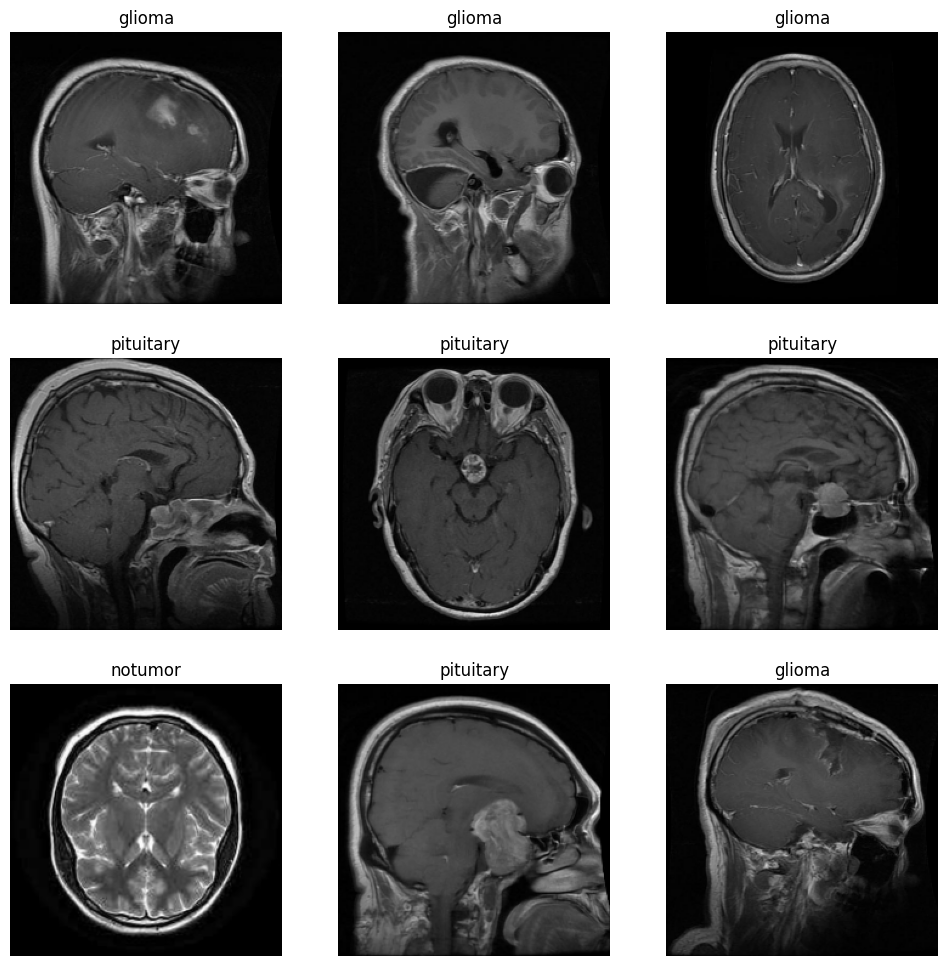

In [4]:

plt.figure(figsize=(12, 12))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [5]:

def print_count_and_plot(data,name,pallete_style="deep"):
    i=0

    ds=pd.DataFrame({'Class':["meningioma","glioma","notumor","pituitary"],'Count':[0,0,0,0]})
    
    #Looping over the data
    for images, labels in data:
        for i in range(len(images)):
            if class_names[labels[i]] == 'meningioma':
                ds.loc[ds['Class']=='meningioma','Count']+=1
            elif class_names[labels[i]] == 'notumor':
                ds.loc[ds['Class']=='notumor','Count']+=1
            elif class_names[labels[i]] == 'glioma':
                ds.loc[ds['Class']=='glioma','Count']+=1
            elif class_names[labels[i]] == 'pituitary':
                ds.loc[ds['Class']=='pituitary','Count']+=1   
        i+=1
                
    print("Meningioma : " + str(ds.loc[ds['Class']=='meningioma','Count']))
    print("Glioma : " + str(ds.loc[ds['Class']=='glioma','Count']))
    print("No_Tumor : " + str(ds.loc[ds['Class']=='notumor','Count']))
    print("Pituitary : " + str(ds.loc[ds['Class']=='pituitary','Count']))
    print(i)

    #print plot
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=ds , x='Class',y='Count', palette=pallete_style)
    sns.set(style="dark",palette="colorblind")
    plt.title('Count of images in each class of '+name, fontsize=20)
    ax.bar_label(ax.containers[0])
    plt.show()




<h1 style="color:Red;">Checking Imbalanced data</h1>

Meningioma : 0    1339
Name: Count, dtype: int64
Glioma : 1    1321
Name: Count, dtype: int64
No_Tumor : 2    1595
Name: Count, dtype: int64
Pituitary : 3    1457
Name: Count, dtype: int64
16


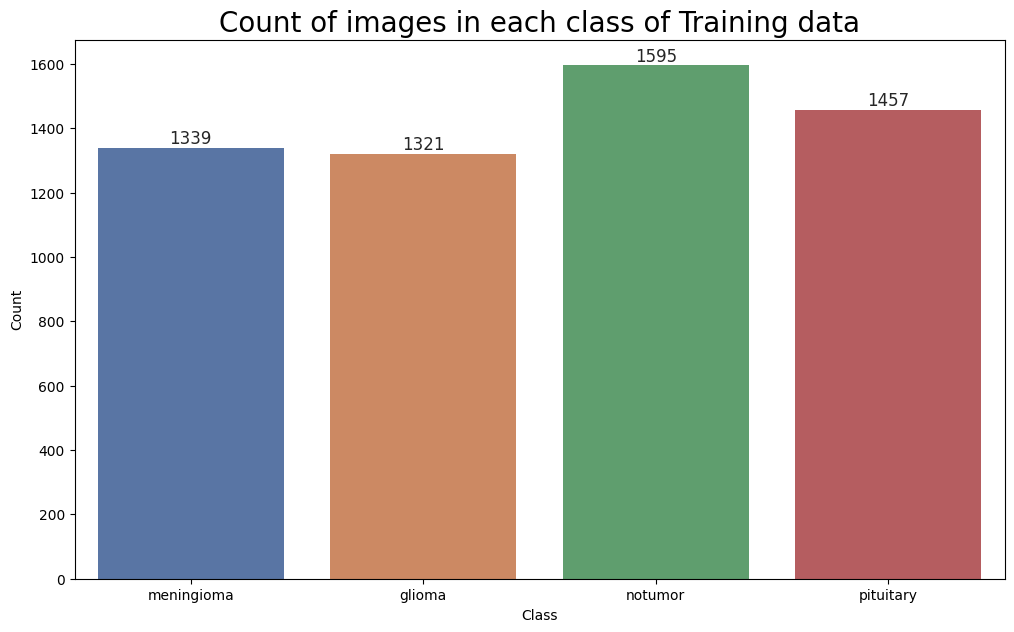

In [6]:
print_count_and_plot(train_data,"Training data")

Meningioma : 0    306
Name: Count, dtype: int64
Glioma : 1    300
Name: Count, dtype: int64
No_Tumor : 2    405
Name: Count, dtype: int64
Pituitary : 3    300
Name: Count, dtype: int64
31


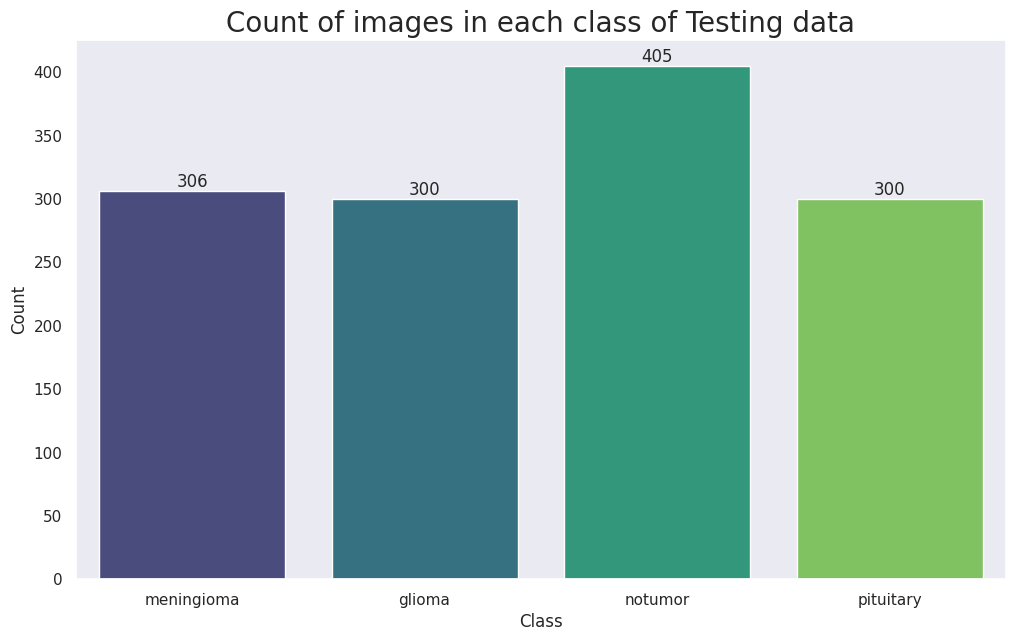

In [7]:
print_count_and_plot(test_data,"Testing data",pallete_style='viridis')

In [33]:
callback_list=[
    callbacks.EarlyStopping(monitor="val_accuracy",patience=10,restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.8,monitor="val_accuracy",patience=3)
]

In [200]:

image_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetB0(include_top = False) #excluding the top layer 

base_model.trainable = False

model = Sequential([
    base_model,
    Conv2D(32, 3, padding='same', activation="relu", name="Top_Conv_Layer"),
    GlobalAveragePooling2D(name="Global_avg_Pooling_2D"),
    Flatten(),
    Dropout(0.3),
    Dense(4, activation="sigmoid", name="Output_layer")
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy', Precision(), Recall()]  # Include precision and recall
)

model.summary()


Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 Top_Conv_Layer (Conv2D)     (None, None, None, 32)    368672    
                                                                 
 Global_avg_Pooling_2D (Glo  (None, 32)                0         
 balAveragePooling2D)                                            
                                                                 
 flatten_16 (Flatten)        (None, 32)                0         
                                                                 
 dropout_12 (Dropout)        (None, 32)                0         
                                                                 
 Output_layer (Dense)        (None, 4)               

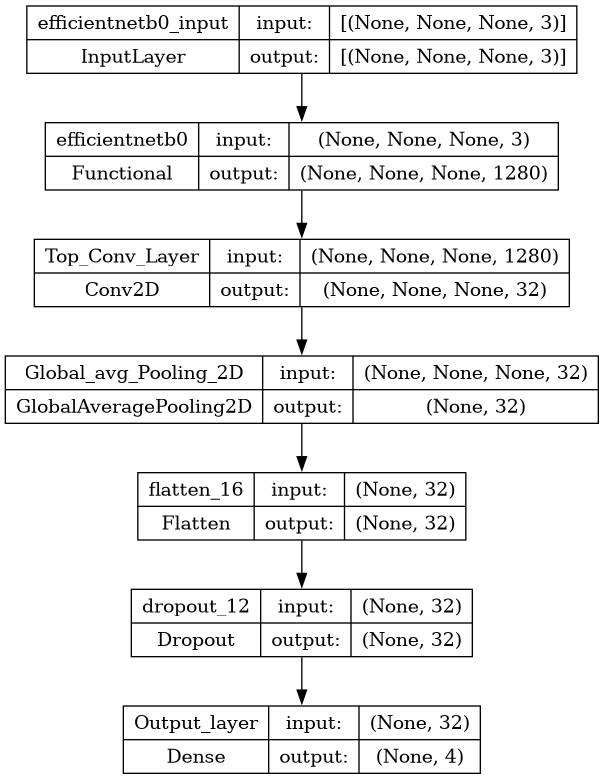

In [201]:
tf.keras.utils.plot_model(model, show_shapes=True)

<h3>First Stage Training<h3>
<h4 style="color:red;">=> BaseModel(Freezed) . add[Global avg pooling layer] <h4>
<h4 style="color:red;">=>Conv2D layer(will help us in the segmentation part)<h4>

In [202]:
Model_History = model.fit(train_data 
                              ,validation_data = test_data ,
                              epochs = 5  ,
                              verbose = 1 ,
                              callbacks = callback_list)

Epoch 1/5


2024-02-10 01:19:13.978179: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_24/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


179/179 [==============================] - 19s 66ms/step - loss: 0.4713 - accuracy: 0.8202 - precision_19: 0.5834 - recall_19: 0.9349 - val_loss: 0.3123 - val_accuracy: 0.8757 - val_precision_19: 0.6354 - val_recall_19: 0.9756 - lr: 0.0010
Epoch 2/5
179/179 [==============================] - 10s 56ms/step - loss: 0.2842 - accuracy: 0.8925 - precision_19: 0.6152 - recall_19: 0.9709 - val_loss: 0.2258 - val_accuracy: 0.9077 - val_precision_19: 0.6519 - val_recall_19: 0.9901 - lr: 0.0010
Epoch 3/5
179/179 [==============================] - 10s 56ms/step - loss: 0.2173 - accuracy: 0.9177 - precision_19: 0.6416 - recall_19: 0.9807 - val_loss: 0.2013 - val_accuracy: 0.9161 - val_precision_19: 0.6599 - val_recall_19: 0.9901 - lr: 0.0010
Epoch 4/5
179/179 [==============================] - 10s 56ms/step - loss: 0.1775 - accuracy: 0.9342 - precision_19: 0.6438 - recall_19: 0.9862 - val_loss: 0.1585 - val_accuracy: 0.9375 - val_precision_19: 0.7059 - val_recall_19: 0.9962 - lr: 0.0010
Epoch 5/5


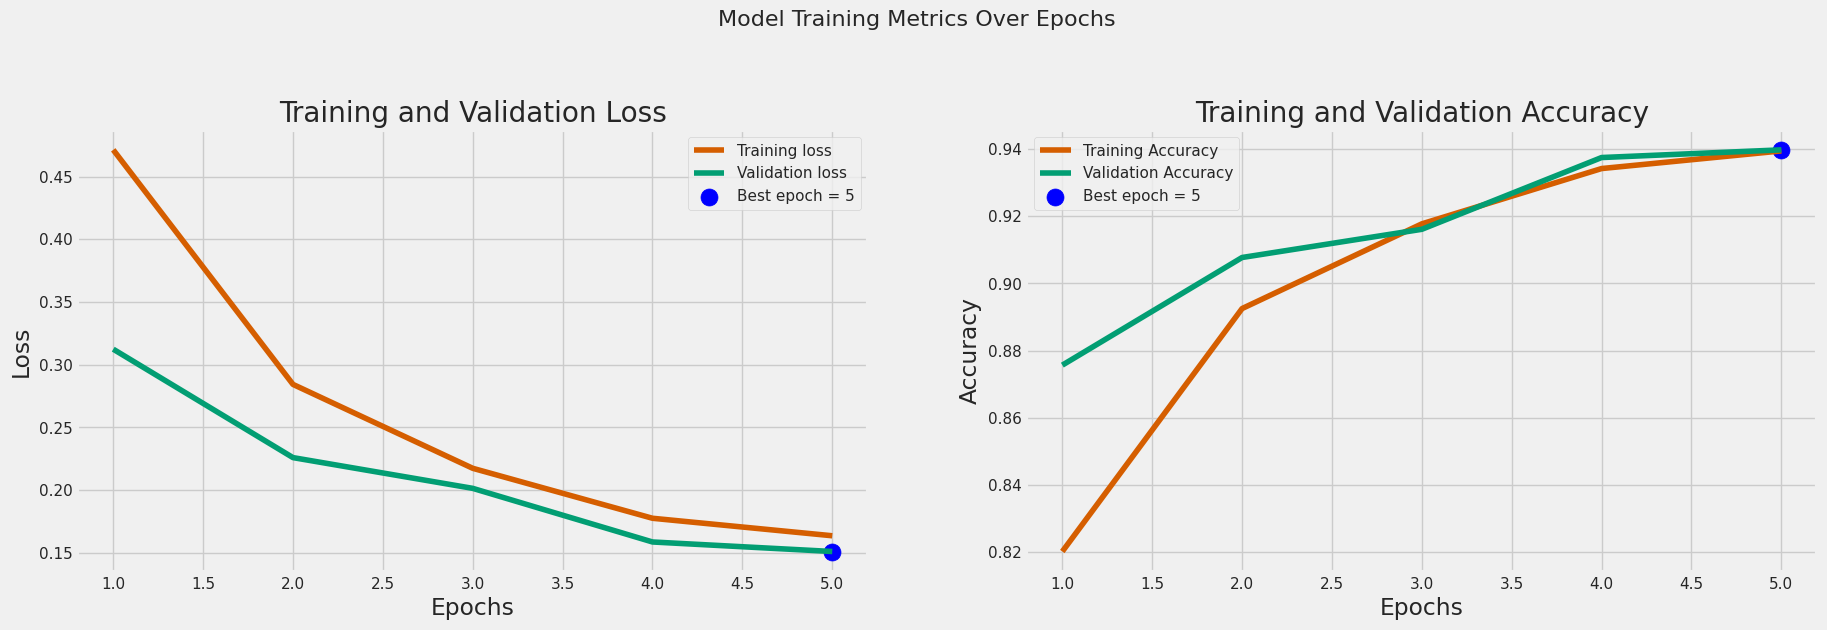

In [203]:
train_acc = Model_History.history['accuracy']
train_loss = Model_History.history['loss']
val_acc =  Model_History.history['val_accuracy']
val_loss =  Model_History.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]


Epochs = [i + 1 for i in range(len(train_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'



plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, train_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

<h3>Second Stage Training<h3>
<h4 style="color:red;">=>unfreaze Last 10 Layers of the Base model<h4>
<h4 style="color:red;">=>Lower the learning rate of Adam optimizer<h4>

In [204]:
base_model.trainable = True

#Freezing all the layers except last 10 
for layer in base_model.layers[:-10]:
    layer.trainable = False


#ReCompile the model 
model.compile(loss = "categorical_crossentropy" ,
                optimizer = tf.keras.optimizers.Adam(learning_rate= 0.0001), #FineTuning by lowering the LR by 10 times
                metrics = ["accuracy"]
               )


#FineTune for 10 epochs 
initial_epoch = 5

Fine_Tune_epoch = initial_epoch + 5

#Refit the model 
Stage_2_history = model.fit(train_data ,
                              epochs = Fine_Tune_epoch , 
                              validation_data = test_data ,
                              validation_steps = len(test_data) ,
                              initial_epoch = initial_epoch-1)

Epoch 5/10


2024-02-10 01:20:30.460805: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_24/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


179/179 [==============================] - 20s 65ms/step - loss: 0.1714 - accuracy: 0.9400 - val_loss: 0.1201 - val_accuracy: 0.9527
Epoch 6/10
179/179 [==============================] - 10s 56ms/step - loss: 0.1155 - accuracy: 0.9575 - val_loss: 0.1033 - val_accuracy: 0.9573
Epoch 7/10
179/179 [==============================] - 10s 57ms/step - loss: 0.0916 - accuracy: 0.9681 - val_loss: 0.0882 - val_accuracy: 0.9626
Epoch 8/10
179/179 [==============================] - 10s 57ms/step - loss: 0.0780 - accuracy: 0.9743 - val_loss: 0.0761 - val_accuracy: 0.9695
Epoch 9/10
179/179 [==============================] - 10s 56ms/step - loss: 0.0733 - accuracy: 0.9741 - val_loss: 0.0720 - val_accuracy: 0.9680
Epoch 10/10
179/179 [==============================] - 10s 57ms/step - loss: 0.0652 - accuracy: 0.9776 - val_loss: 0.0815 - val_accuracy: 0.9710


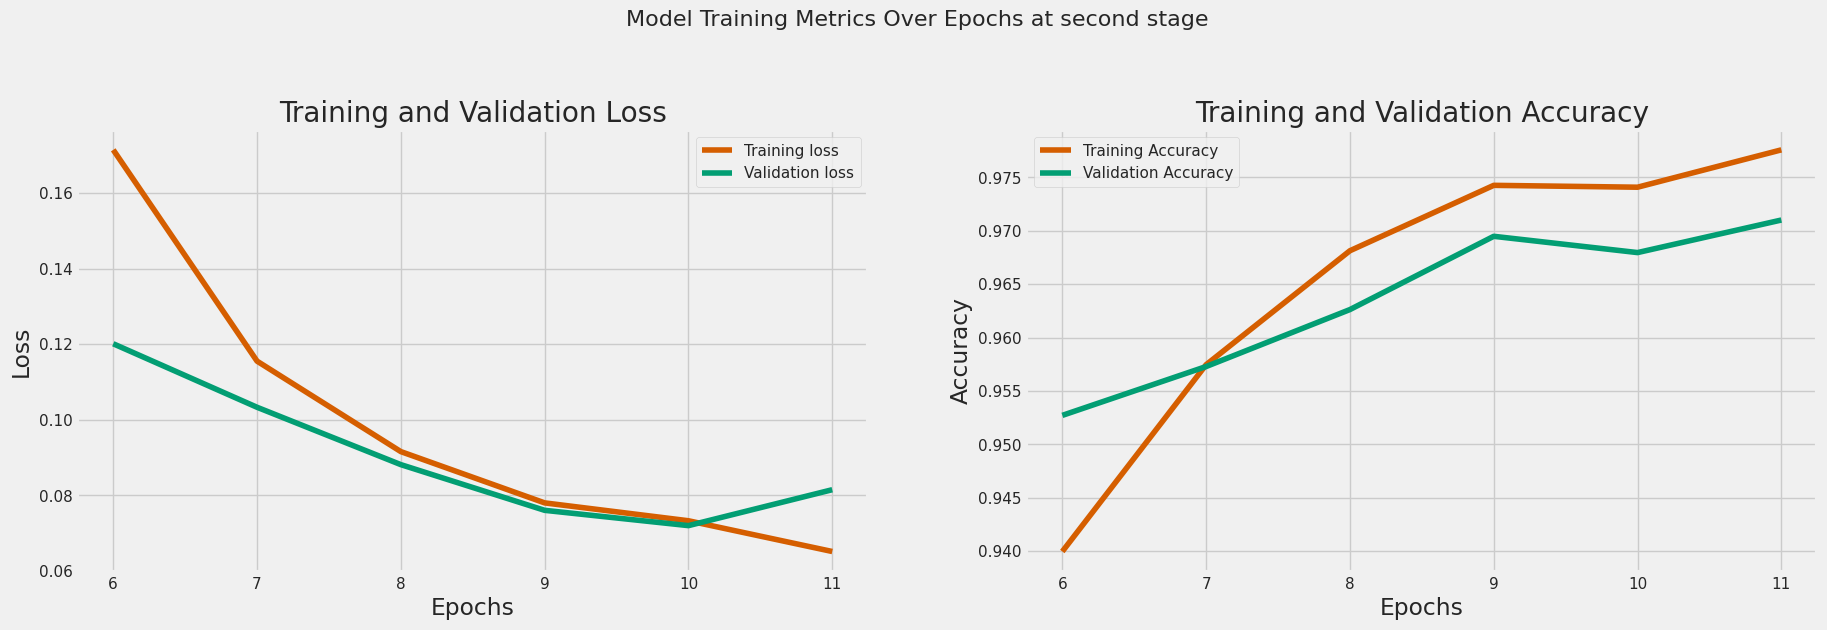

In [205]:
train_acc = Stage_2_history.history['accuracy']
train_loss = Stage_2_history.history['loss']
val_acc =  Stage_2_history.history['val_accuracy']
val_loss =  Stage_2_history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]


Epochs = [i + 1 for i in range(5,11)]




plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, train_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.suptitle('Model Training Metrics Over Epochs at second stage', fontsize=16)
plt.show()

<h1 style="color:red;">Model Evaluation <h1>

In [206]:
train_score = model.evaluate(train_data, verbose=1)
test_score = model.evaluate(test_data,verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

41/41 [==============================] - 2s 43ms/step - loss: 0.0815 - accuracy: 0.9710
Train Loss: 0.0175
Train Accuracy: 99.54%
--------------------
Test Loss: 0.0815
Test Accuracy: 97.10%


<h2 style="color:blue;">Classification Report <h2>

In [207]:
print(classification_report(true_labels, predicted_labels,target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.99      0.90      0.94       300
  meningioma       0.91      0.98      0.94       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      1.00      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



In [208]:
true_labels = []
predicted_labels = []

for images, labels in test_data:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot encoded labels to class indices
    predicted_labels.extend(np.argmax(model.predict(images), axis=1))  # Obtain model predictions


1/1 [==============================] - 2s 2s/step


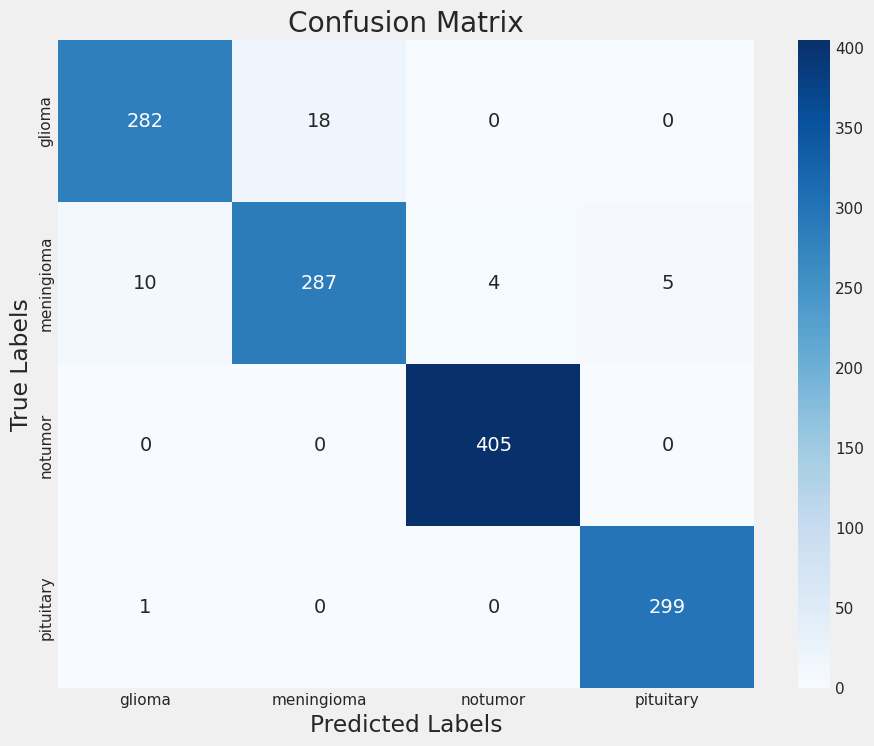

In [209]:

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [167]:
model.save('/kaggle/working/tumor_model.h5')

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


<h1 style="color:red">Segmentation using Grad-Cam</h1>

In [211]:

last_conv_layer_name = "Top_Conv_Layer"

def get_img_array(img_path, size = (224 , 224)):
    img = keras.utils.load_img(img_path, target_size=size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array



def make_gradcam_heatmap(img_array, model = model , last_conv_layer_name = last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis] #matrix multiply
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4 , view = False):
    # Load the original image
    img = keras.utils.load_img(img_path)
    img = keras.utils.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = mpl.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    if view :
        display(Image(cam_path))

        
     

def decode_predictions(preds):
    classes = ['Glioma' , 'meningioma' , 'No Tumor' , 'Pituitary']
    prediction = classes[np.argmax(preds)]
    return prediction



def make_prediction (img_path , model = model , last_conv_layer_name = last_conv_layer_name , campath = "cam.jpeg" , view = False):
    img = get_img_array(img_path = img_path)
    img_array = get_img_array(img_path, size=(224 , 224))
    preds = model.predict(img_array)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    save_and_display_gradcam(img_path, heatmap , cam_path=campath , view = view)
    return [campath , decode_predictions(preds)]

1/1 [==============================] - 0s 27ms/step
meningioma


(-0.5, 317.5, 353.5, -0.5)

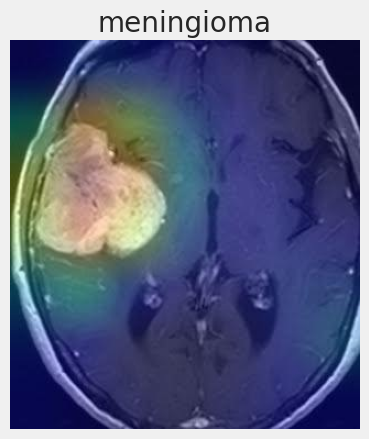

In [212]:


campath , prediction = make_prediction("/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0025.jpg" , campath="123.jpeg" , view = False)
print(prediction)
test_img = img.imread(campath)
plt.imshow(test_img)
plt.title(prediction)
plt.axis("off")

1/1 [==============================] - 0s 24ms/step


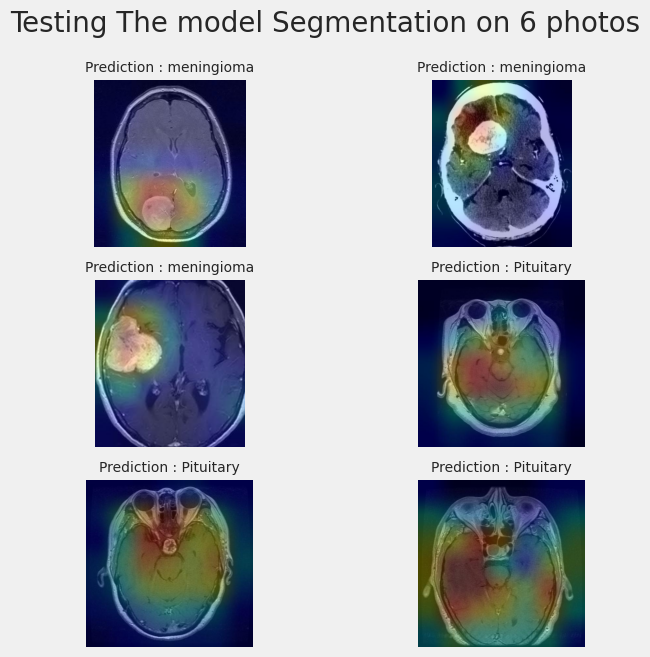

In [213]:
#Define photos paths :
path_array = [
  '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0010.jpg',
  '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0015.jpg' ,
  '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0025.jpg' ,
  '/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_0010.jpg' ,
  '/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_0021.jpg' ,
  '/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_0030.jpg' ,

]


fig = plt.figure(figsize=(7, 7))
fig.suptitle("Testing The model Segmentation on 6 photos" , fontsize = 20)
for images, labels in train_data.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i + 1)
        campath , prediction = make_prediction(path_array[i] , campath=f"{i}.jpeg")
        test_img = img.imread(campath)
        plt.imshow(test_img)
        plt.title("Prediction : " + prediction, fontsize = 10)
        plt.axis("off")

In [214]:

def predict(img_path):
   
    label = class_names
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    print(probs)
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 [==============================] - 1s 1s/step
[0.9999695, 0.0057213265, 0.044850703, 0.00073928933]


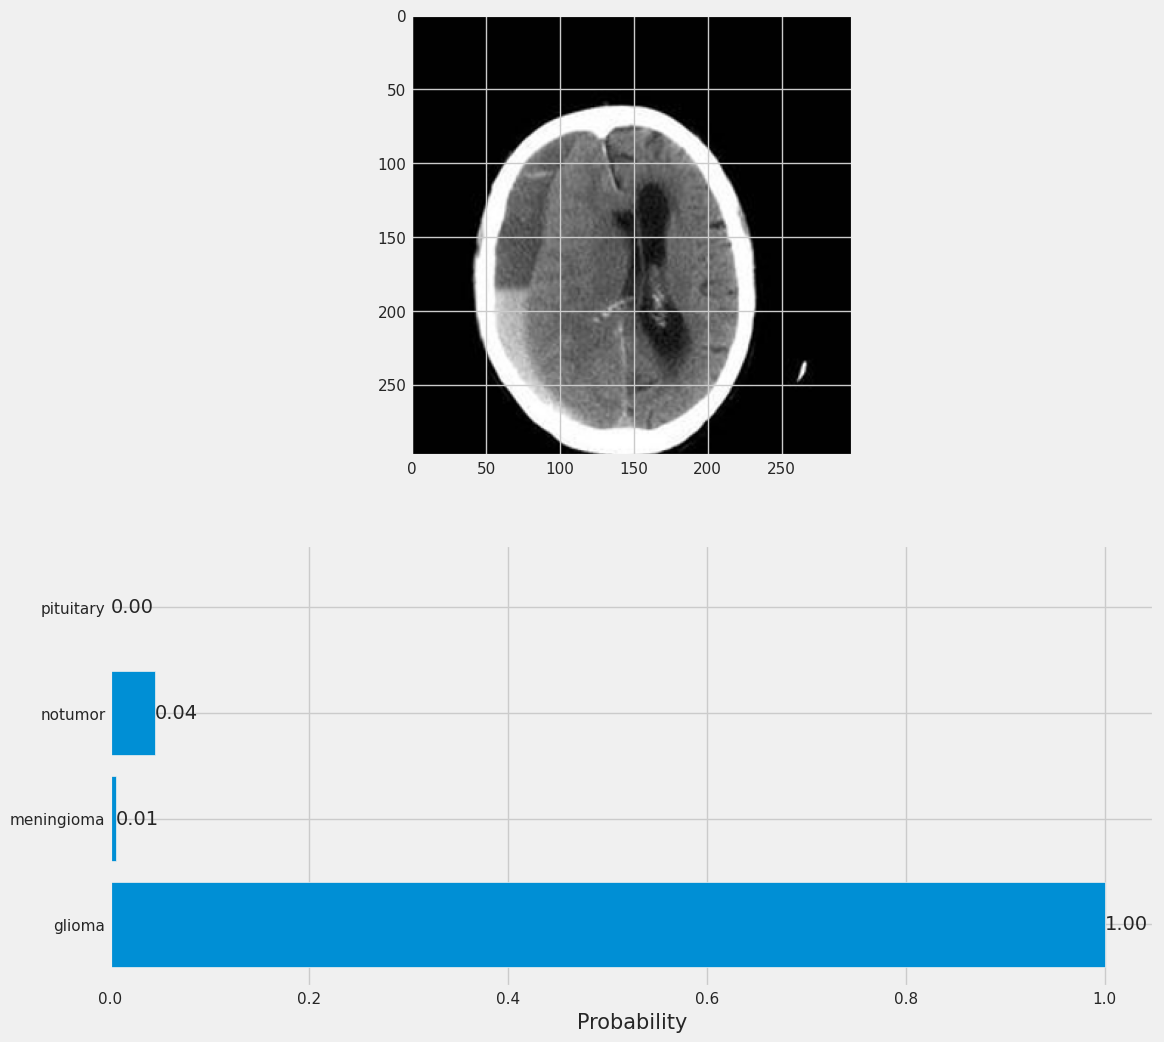

In [215]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0000.jpg')

1/1 [==============================] - 0s 27ms/step
[0.9999695, 0.0055802693, 0.045922883, 0.0007453322]


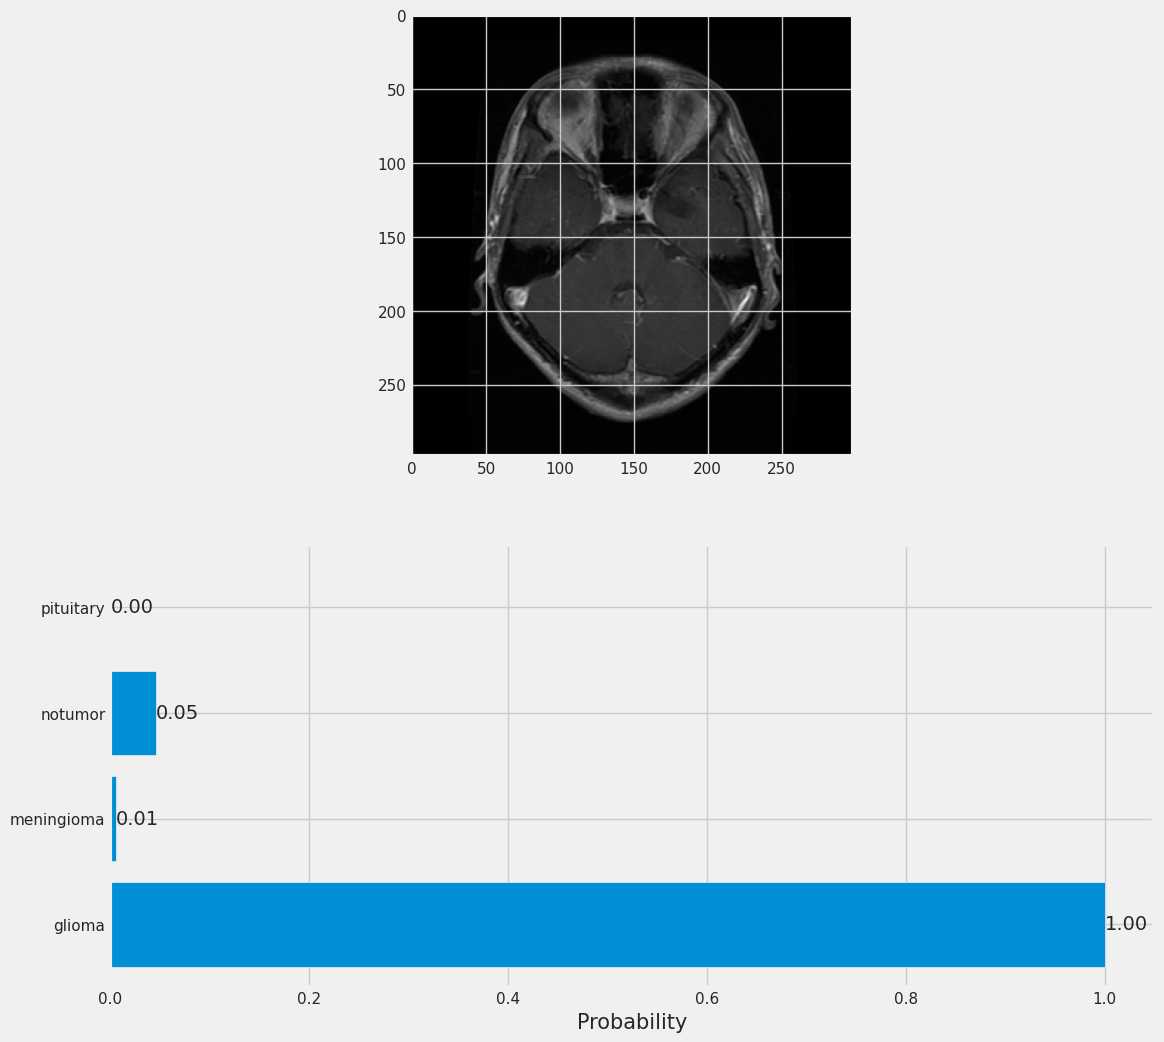

In [216]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0001.jpg')

1/1 [==============================] - 0s 25ms/step
[0.9999696, 0.005629763, 0.045351095, 0.0007422383]


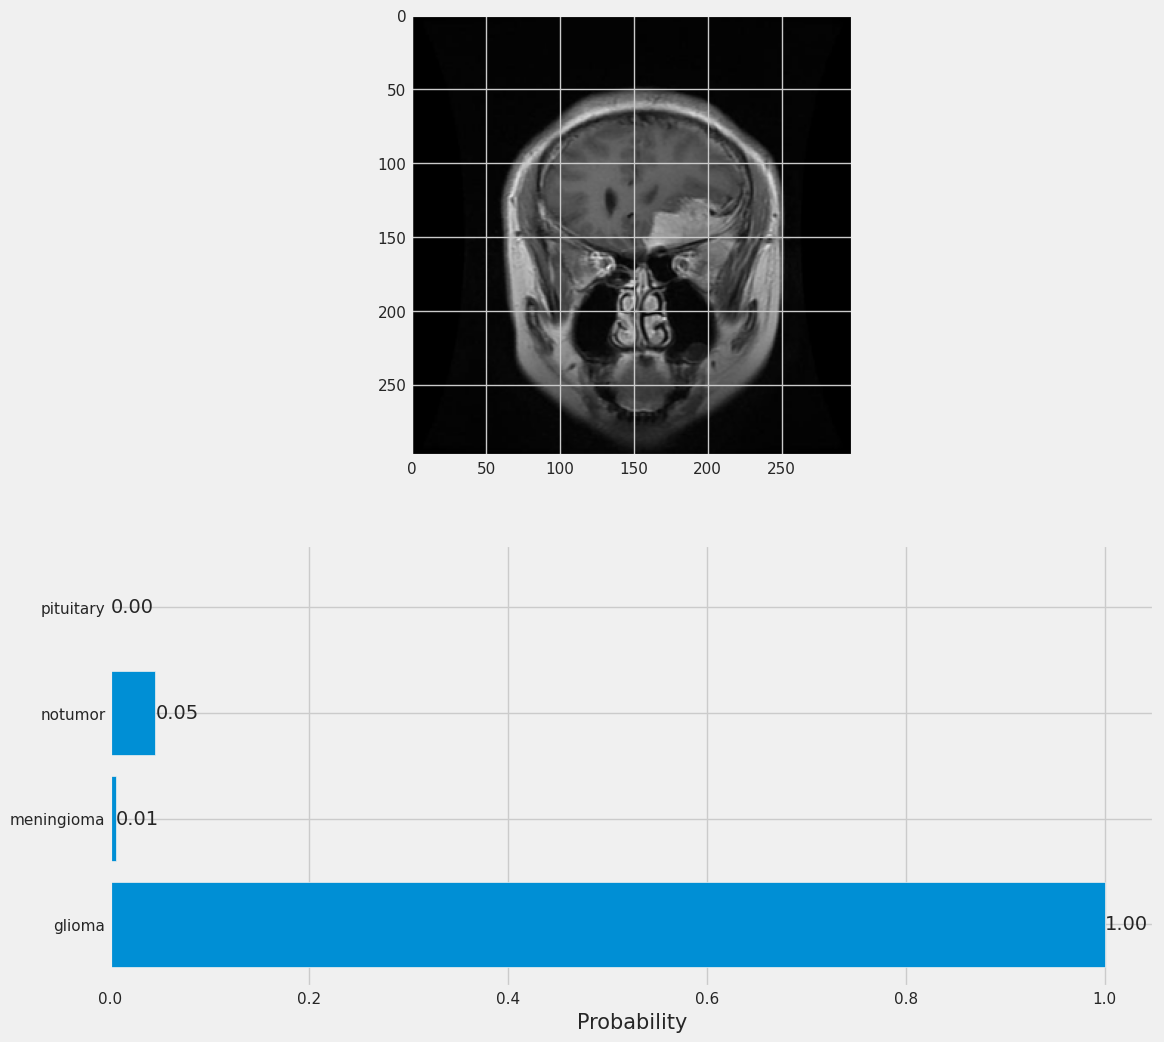

In [217]:
predict('/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-meTr_0000.jpg')